# Training a ResNet50 CNN Model
**Authors:** Dickson Owuor, Raymond Cao

August 2025

## Main Goal

To train a CNN model from scratch to predict "good" and "bad" graphs. We are using a **PyTorch** training script.

In [ ]:
# Installing Libraries (if not installed)
#!pip install torch torchvision

In [18]:
# Import Libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

### Choose the device and Hyperparameters

In [2]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
num_epochs = 25
batch_size = 16
learning_rate = 1e-4
img_size = 224  # ResNet50 input size

Using device: cpu


In [3]:
# Data transformations
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

In [4]:
# Load dataset (all data in good/ and bad/)
dataset_dir = "../train_data/manual"
full_dataset = datasets.ImageFolder(dataset_dir, transform=transform)

In [5]:
# Train/Val split (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [10]:
# Model (ResNet50 from scratch)
model = models.resnet50(weights=None)  # No Pretrained Weights
model.fc = nn.Linear(model.fc.in_features, 2)  # 2 classes: good/bad
model = model.to(device)
#print(model)

In [11]:

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [13]:
# Track performance
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels).item()

    train_loss = running_loss / len(train_dataset)
    train_acc = running_corrects / len(train_dataset)

    # Validation
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels).item()

    val_loss /= len(val_dataset)
    val_acc = val_corrects / len(val_dataset)

    # Save epoch metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch [1/25] Train Loss: 0.9349, Train Acc: 0.4600 Val Loss: 0.7285, Val Acc: 0.5769
Epoch [2/25] Train Loss: 0.7298, Train Acc: 0.5600 Val Loss: 0.6820, Val Acc: 0.5769
Epoch [3/25] Train Loss: 0.7137, Train Acc: 0.5700 Val Loss: 0.6886, Val Acc: 0.6538
Epoch [4/25] Train Loss: 0.6818, Train Acc: 0.5400 Val Loss: 0.6694, Val Acc: 0.6538
Epoch [5/25] Train Loss: 0.7111, Train Acc: 0.4800 Val Loss: 0.6337, Val Acc: 0.5385
Epoch [6/25] Train Loss: 0.6993, Train Acc: 0.4900 Val Loss: 0.6358, Val Acc: 0.5769
Epoch [7/25] Train Loss: 0.6841, Train Acc: 0.5200 Val Loss: 0.6103, Val Acc: 0.6154
Epoch [8/25] Train Loss: 0.7045, Train Acc: 0.5600 Val Loss: 0.6287, Val Acc: 0.7308
Epoch [9/25] Train Loss: 0.6520, Train Acc: 0.5700 Val Loss: 0.8044, Val Acc: 0.5000
Epoch [10/25] Train Loss: 0.7313, Train Acc: 0.5100 Val Loss: 0.5297, Val Acc: 0.7692
Epoch [11/25] Train Loss: 0.6578, Train Acc: 0.6100 Val Loss: 0.7176, Val Acc: 0.5769
Epoch [12/25] Train Loss: 0.6496, Train Acc: 0.6700 Val Loss: 0

### Plot Performance Results

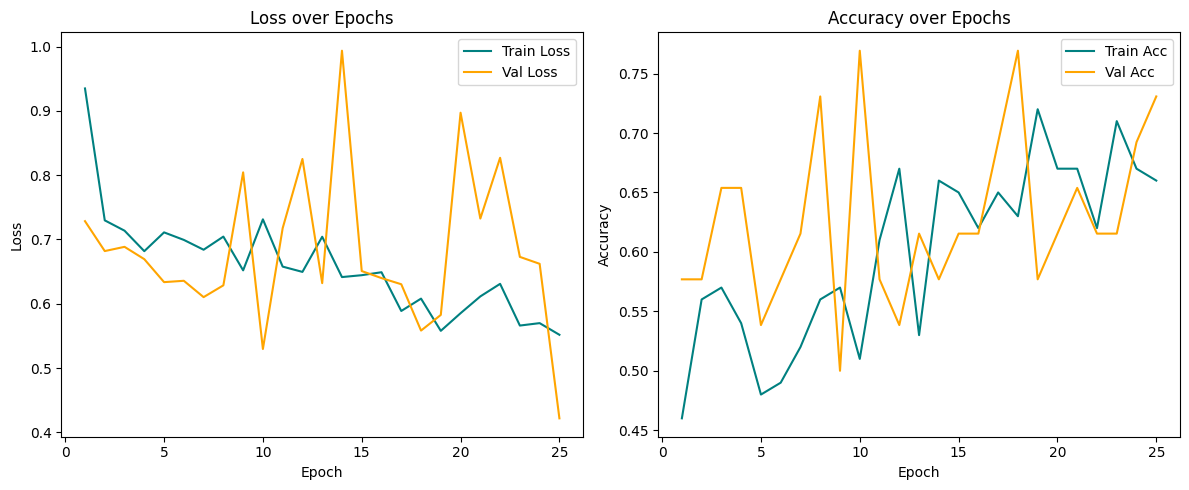

In [14]:
# ---- Plot results ----
epochs = range(1, num_epochs+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax1.plot(epochs, train_losses, label="Train Loss", color="teal")
ax1.plot(epochs, val_losses, label="Val Loss", color="orange")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

# Accuracy
ax2.plot(epochs, train_accuracies, label="Train Acc", color="teal")
ax2.plot(epochs, val_accuracies, label="Val Acc", color="orange")
ax2.set_title("Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
fig.savefig('performance.png', dpi=300)
plt.show()

In [15]:
# Save model
os.makedirs("checkpoints", exist_ok=True)
torch.save(model.state_dict(), "checkpoints/resnet50_sgt.pth")
print("Model saved.")

Model saved.


### Testing Model

In [ ]:
# --- Load your trained model ---
model = models.resnet50(weights=None)   # same definition as training
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, 2)  # assuming 2 classes: "bad" vs "good"

# Load saved weights
model.load_state_dict(torch.load("resnet50_sem.pth", map_location="cpu"))
model.eval()

In [16]:
# --- Image preprocessing ---
img_size = 224  # or whatever you used in training
test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # same as training
])



In [23]:
# --- Load your PNG image ---
img_path = "../train_data/auto/auto_images/4.tif__run00000__0885d862.png"
img_path = "../train_data/manual/good/ANF_good3.png"
img_path = "../train_data/manual/bad/ANF_bad3.png"
image = Image.open(img_path).convert("RGB")
image = test_transform(image).unsqueeze(0)  # add batch dimension

# --- Inference ---
with torch.no_grad():
    outputs = model(image)
    _, preds = torch.max(outputs, 1)

# --- Map prediction to label ---
class_names = ["bad", "good"]  # same order as your dataset class indices
pred_label = class_names[preds.item()]

print(f"Predicted class for {img_path}: {pred_label}")

Predicted class for ../train_data/manual/bad/ANF_bad3.png: good
